# Data Engineering & EDA Workshop

This notebook demonstrates an end-to-end data engineering workflow using a cloud PostgreSQL database, Python, Pandas, and data visualization. The project includes data collection, cleaning, transformation, feature engineering, scaling, exploratory data analysis, and visualization.

In [1]:
import pandas as pd
import psycopg2
from faker import Faker
import random
from datetime import date
import os
from dotenv import load_dotenv

## 1. Data Collection

The employee dataset is synthetically generated using Python and the Faker library. The data includes employee names, IT-related job positions, start dates between 2015 and 2024, and salaries ranging from $60,000 to $200,000.

The generated employee records will be stored in a cloud PostgreSQL database hosted on Neon. Python will then connect to the database using psycopg2, and the data will be loaded into a Pandas DataFrame for analysis.

In [2]:
# Create a Faker object for generating fake employee names and dates
fake = Faker()

# List of possible IT-related job positions
positions = [
    "Software Developer",
    "Data Analyst",
    "Data Engineer",
    "Database Administrator",
    "Network Engineer",
    "Cybersecurity Analyst",
    "Cloud Engineer",
    "Systems Administrator"
]

# Empty list that will store the generated employees
employees = []

# Generate 50 employee records
for employee_id in range(1, 51):
    employee = (
        employee_id,
        fake.name(),
        random.choice(positions),
        fake.date_between(
            start_date=date(2015, 1, 1),
            end_date=date(2024, 12, 31)
        ),
        random.randint(60000, 200000)
    )

    # Add the employee record to the list
    employees.append(employee)

In [3]:
# Check that 50 employees were generated
print("Number of employees:", len(employees))

# Display the first generated employee
print("\nFirst employee:")
print(employees[0])

Number of employees: 50

First employee:
(1, 'Julie Nichols', 'Network Engineer', datetime.date(2024, 12, 9), 144254)


In [4]:
# Load variables stored in the .env file
load_dotenv()

# Get the Neon database connection string
database_url = os.getenv("DATABASE_URL")

# Check that the connection string was loaded without displaying the password
print("Database URL loaded:", database_url is not None)

Database URL loaded: True


In [5]:
# Connect to the Neon PostgreSQL database
connection = psycopg2.connect(database_url)

print("Connected to Neon PostgreSQL successfully!")

# Close the database connection after testing it
connection.close()

Connected to Neon PostgreSQL successfully!


In [6]:
# Connect to the Neon PostgreSQL database
connection = psycopg2.connect(database_url)

# Create a cursor to execute SQL commands
cursor = connection.cursor()

# SQL command for inserting an employee
insert_query = """
INSERT INTO employees (employee_id, name, position, start_date, salary)
VALUES (%s, %s, %s, %s, %s)
ON CONFLICT (employee_id) DO NOTHING;
"""

# Insert all 50 employee records
cursor.executemany(insert_query, employees)

# Save the changes to the database
connection.commit()

print("50 employees inserted successfully!")

# Close the cursor and database connection
cursor.close()
connection.close()

50 employees inserted successfully!


In [7]:
# Connect to the Neon PostgreSQL database
connection = psycopg2.connect(database_url)

# Query all employee records and load them into a Pandas DataFrame
query = "SELECT * FROM employees;"

df = pd.read_sql(query, connection)

# Close the database connection
connection.close()

# Display the first five rows
df.head()

C:\Users\sybun\AppData\Local\Temp\ipykernel_20044\953469716.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,employee_id,name,position,start_date,salary
0,1,Melissa Vaughan,Software Developer,2024-03-05,186460
1,2,Mark Tran,Network Engineer,2024-04-23,164559
2,3,Charles Potts,Database Administrator,2019-02-26,72659
3,4,Blake Allen,Cybersecurity Analyst,2016-06-24,78156
4,5,Judith Sharp,Network Engineer,2016-11-15,165792


## 2. Data Cleaning

Before analyzing the employee data, the dataset will be inspected for missing values, incorrect data types, duplicate records, and other potential data quality issues.

In [8]:
# Display information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   employee_id  50 non-null     int64 
 1   name         50 non-null     str   
 2   position     50 non-null     str   
 3   start_date   50 non-null     object
 4   salary       50 non-null     int64 
dtypes: int64(2), object(1), str(2)
memory usage: 2.1+ KB


In [9]:
# Check each column for missing values
df.isnull().sum()

employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64

In [10]:
# Check the number of duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
# Display descriptive statistics for the numeric columns
df.describe()

,employee_id,salary
count,50.00000,50.000000
mean,25.50000,125612.960000
std,14.57738,39101.012501
min,1.00000,63271.000000
25%,13.25000,95587.000000
50%,25.50000,116160.000000
75%,37.75000,151568.250000
max,50.00000,198532.000000


## 3. Data Transformation & Feature Engineering

The employee data is transformed by extracting the employee's start year from the start date. A new feature called `years_of_service` is also created to represent how many years each employee has worked at the company. These derived features will make the data easier to analyze and visualize.

In [12]:
# Convert start_date to Pandas datetime format
df["start_date"] = pd.to_datetime(df["start_date"])

# Extract the year each employee started
df["start_year"] = df["start_date"].dt.year

# Calculate years of service through the end of 2024
df["years_of_service"] = 2024 - df["start_year"]

# Display the updated DataFrame
df.head()

,employee_id,name,position,start_date,salary,start_year,years_of_service
0,1,Melissa Vaughan,Software Developer,2024-03-05,186460,2024,0
1,2,Mark Tran,Network Engineer,2024-04-23,164559,2024,0
2,3,Charles Potts,Database Administrator,2019-02-26,72659,2019,5
3,4,Blake Allen,Cybersecurity Analyst,2016-06-24,78156,2016,8
4,5,Judith Sharp,Network Engineer,2016-11-15,165792,2016,8


## 4. Scaling

Salary is a numeric feature with relatively large values. Standardization is applied to transform salary values so they are measured relative to the mean and standard deviation. This creates a new `salary_scaled` column while preserving the original salary values.

In [13]:
# Import StandardScaler for scaling numeric data
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Standardize salary and store the result in a new column
df["salary_scaled"] = scaler.fit_transform(df[["salary"]])

# Display the original and scaled salary values
df[["salary", "salary_scaled"]].head()

,salary,salary_scaled
0,186460,1.571949
1,164559,1.006149
2,72659,-1.368036
3,78156,-1.226024
4,165792,1.038003


## 5. Visualization 1: Average Salary by Position and Start Year

This visualization compares the average employee salary across different IT positions and start years. Grouping the data by position and year helps identify differences in salary across job roles and hiring periods.

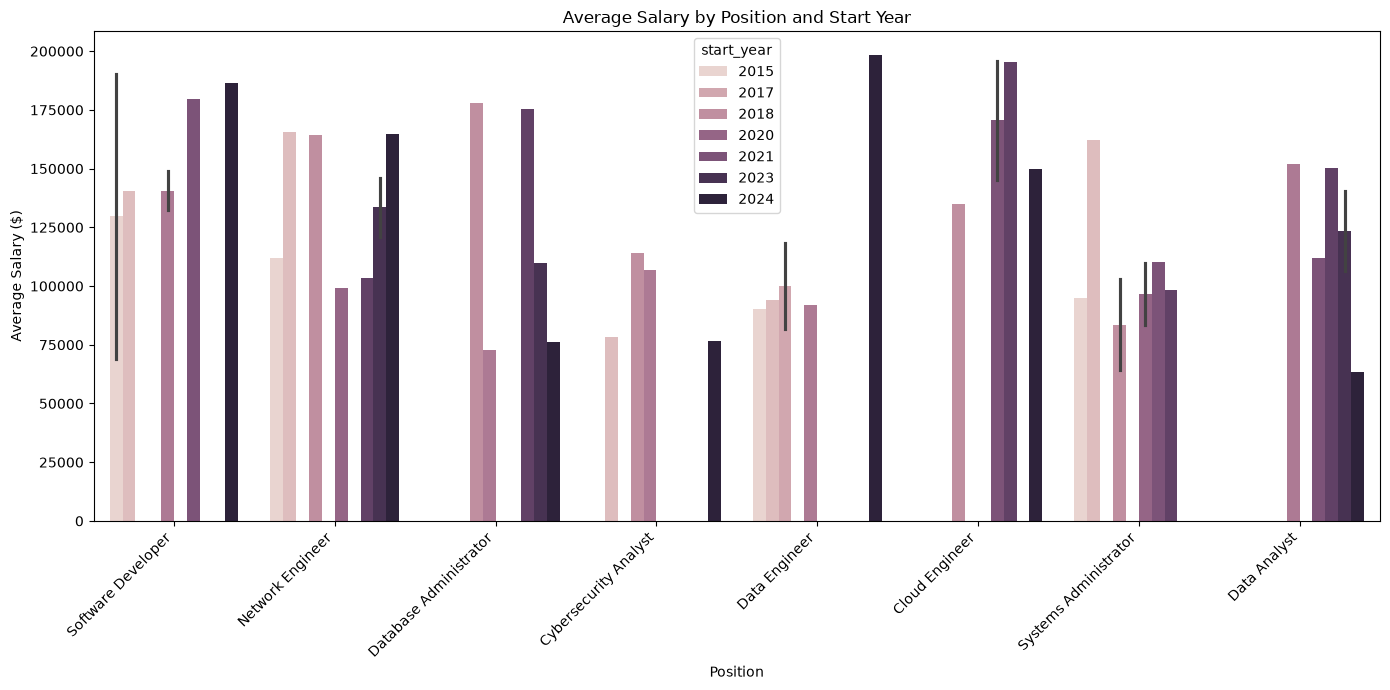

In [14]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a grouped bar chart of average salary by position and start year
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="position",
    y="salary",
    hue="start_year",
    estimator="mean"
)

# Add labels and title
plt.title("Average Salary by Position and Start Year")
plt.xlabel("Position")
plt.ylabel("Average Salary ($)")

# Rotate job titles so they are easier to read
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6. Visualization 2: Department and Salary Analysis

To create a more complex dataset, additional department information will be generated and joined with the employee data. This will allow salary patterns to be analyzed across both job positions and departments.

In [15]:
# Create department information for the advanced analysis
departments = pd.DataFrame({
    "department_id": [1, 2, 3, 4],
    "department": [
        "Software Development",
        "Data & Analytics",
        "Infrastructure",
        "Cybersecurity"
    ],
    "location": [
        "Toronto",
        "Kitchener",
        "Waterloo",
        "Toronto"
    ],
    "budget": [
        1500000,
        1200000,
        1000000,
        900000
    ]
})

# Display the department data
departments

,department_id,department,location,budget
0,1,Software Development,Toronto,1500000
1,2,Data & Analytics,Kitchener,1200000
2,3,Infrastructure,Waterloo,1000000
3,4,Cybersecurity,Toronto,900000


In [16]:
# Match each job position to a department
position_to_department = {
    "Software Developer": 1,
    "Data Analyst": 2,
    "Data Engineer": 2,
    "Database Administrator": 3,
    "Network Engineer": 3,
    "Cloud Engineer": 3,
    "Systems Administrator": 3,
    "Cybersecurity Analyst": 4
}

# Create a department_id column based on employee position
df["department_id"] = df["position"].map(position_to_department)

# Display the new department assignments
df[["name", "position", "department_id"]].head()

,name,position,department_id
0,Melissa Vaughan,Software Developer,1
1,Mark Tran,Network Engineer,3
2,Charles Potts,Database Administrator,3
3,Blake Allen,Cybersecurity Analyst,4
4,Judith Sharp,Network Engineer,3


In [17]:
# Join the employee data with the department data
merged_df = pd.merge(
    df,
    departments,
    on="department_id",
    how="left"
)

# Display part of the combined dataset
merged_df[
    ["name", "position", "department", "location", "salary"]
].head()

,name,position,department,location,salary
0,Melissa Vaughan,Software Developer,Software Development,Toronto,186460
1,Mark Tran,Network Engineer,Infrastructure,Waterloo,164559
2,Charles Potts,Database Administrator,Infrastructure,Waterloo,72659
3,Blake Allen,Cybersecurity Analyst,Cybersecurity,Toronto,78156
4,Judith Sharp,Network Engineer,Infrastructure,Waterloo,165792


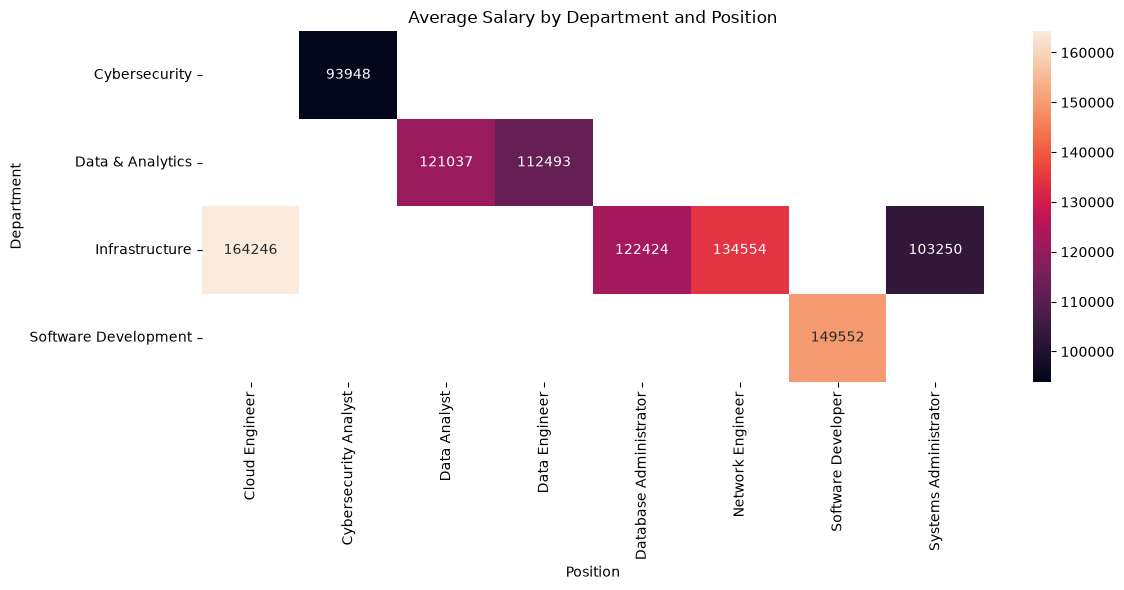

In [18]:
# Calculate the average salary for each department and position
salary_heatmap = merged_df.pivot_table(
    values="salary",
    index="department",
    columns="position",
    aggfunc="mean"
)

# Create the heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    salary_heatmap,
    annot=True,
    fmt=".0f"
)

plt.title("Average Salary by Department and Position")
plt.xlabel("Position")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

## 7. Insights & Conclusions

### Visualization 1: Average Salary by Position and Start Year

The grouped bar chart shows noticeable differences in average salary across IT positions and start years. Cloud Engineers and Software Developers show some of the higher salaries in the dataset, while Cybersecurity Analysts generally show lower salaries. Salaries also vary considerably by start year within several positions. Because the dataset contains only 50 randomly generated employees, some position and year combinations have few or no employees, which explains the gaps in the chart.

### Visualization 2: Department and Position Salary Analysis

The heatmap shows differences in average salary across departments and positions. Cloud Engineers in the Infrastructure department have the highest average salary at approximately \$164,246, followed by Software Developers in the Software Development department at approximately \$149,552. Cybersecurity Analysts have the lowest average salary at approximately \$93,948. The visualization also clearly shows how each IT position is associated with its assigned department.

### Conclusion

This project demonstrated an end-to-end data engineering workflow. Synthetic employee data was generated with Python, stored in a cloud PostgreSQL database, retrieved using psycopg2 and Pandas, cleaned and transformed, and used to create new features. Salary data was also standardized, and an additional department dataset was joined with the employee data to support more advanced analysis and visualization.